<a href="https://colab.research.google.com/github/ChidiTonio/Digital-currency-adoption-Intensity_factor_analyzer_/blob/main/Factor_analyzer_Xboost_SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Install and Import Required Packages

!pip install factor_analyzer xgboost shap openpyxl statsmodels scikit-learn --quiet



In [30]:
# Re-install required packages
!pip install factor_analyzer xgboost shap openpyxl statsmodels scikit-learn --quiet

In [31]:
# ============================================================
# STEP 2: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

from google.colab import files

from scipy import stats
from scipy.stats import skew, kurtosis, norm

from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.families.links import Probit
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
import shap

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)


### Uploading our Primary Dataset

Your file should be your final cleaned primary dataset, preferably in CSV or Excel format.

It must contain your final N = 850 observations.

In [32]:
# ============================================================
# STEP 3: UPLOAD YOUR DATASET
# ============================================================

uploaded = files.upload()

In [33]:
# ============================================================
# STEP 4: LOAD DATA
# ============================================================

# Change this filename to the exact file you uploaded
# Example: "primary_data.csv" or "final_dataset.xlsx"

# Since '02_CLEANED_sme_digital_finance_survey_1000.csv' is already in /content/,
# we will load it directly. If you want to upload a NEW file, run the previous cell.
filename = '/content/02_CLEANED_sme_digital_finance_survey_1000.csv'
print("Loading file from path:", filename)

if filename.endswith(".csv"):
    df = pd.read_csv(filename)
elif filename.endswith(".xlsx") or filename.endswith(".xls"):
    df = pd.read_excel(filename)
else:
    raise ValueError("Please upload a CSV or Excel file.")

print("Dataset shape:", df.shape)
df.head()

Loading file from path: /content/02_CLEANED_sme_digital_finance_survey_1000.csv
Dataset shape: (850, 135)


,respondent_id,consent,decision_role,state,cluster,sector,firm_age_cat,staff_size_cat,registration_status,monthly_turnover_cat,ownership_type,education_level,gender,owner_age_cat,diglit_app_use,diglit_failed_txn,diglit_security,diglit_records,diglit_compare,diglit_teach,DIGLIT,slack_cashflow,slack_device,slack_staff,slack_risk_absorb,slack_training,RES_SLACK,infra_internet,infra_network_peak,infra_power,infra_failed_freq,infra_speed,network_interrupt_freq,infra_failed_freq_rev,network_interrupt_freq_rev,INFRA,trust_money_safe,trust_dispute_resolution,trust_regulator,trust_digital_records,trust_digital_over_manual,trust_fraud_fear,trust_fraud_fear_rev,REG_TRUST,coop_member,coop_funding_received,total_capital_exact,coop_capital_exact,CFR,coop_easier_access,coop_dependence,coop_substitution,coop_digital_encourage,total_capital_cat,coop_capital_cat,ias_experience,ias_settlement_capital,ias_network_support,ias_mentor_influence,ias_advice_reliance,ias_trust_network,ias_digital_influence,ias_traditional_methods,ias_reverse_learning,ias_mentor_influence_norm,ias_advice_reliance_norm,ias_trust_network_norm,ias_digital_influence_norm,ias_traditional_methods_norm,ias_reverse_learning_norm,IAS_INDEX,useful_payment_speed,useful_records,useful_efficiency,useful_market_access,PU,ease_learn,ease_daily_use,ease_train_staff,ease_correct_mistakes,PEOU,security_confidence,security_fraud_worry,security_fraud_worry_rev,security_receipts,security_support,SECURITY,adoption_intensity,digital_sales_pct,digital_use_days,supplier_payment_intensity,digital_supplier_payment_pct,adoption_growth,use_none,use_pos,use_mobile_app,use_ussd,use_web_banking,use_bank_transfer,use_fintech_wallet,use_digital_credit,use_digital_savings,use_digital_insurance,digital_sales_pct_range,eff_cash_time,eff_disputes,eff_records,eff_cost_increase,eff_cost_increase_rev,eff_sales_reach,eff_overall_performance,EFFICIENCY,barrier_poor_network,barrier_unstable_power,barrier_high_charges,barrier_fraud_fear,barrier_failed_txn,barrier_lack_skills,barrier_customer_cash,barrier_supplier_cash,barrier_manual_trust,barrier_lack_device,barrier_cultural_cash,barrier_none,main_barrier,attention_check,attention_pass,response_confidence,survey_mode,survey_date,enumerator_id,REG_TRUST_NORM,IAS_TRUST_INT,high_adoption,low_quality_response
0,R0001,1,1,1,1,3,5,3,4,2,1,4,1,2,3,2,4,2,3.0,3,2.833333,2,3,2,2,2.0,2.2,4,4,5,2,4,2,4,4,4.166667,3,5,4.0,5,5,2,4,4.333333,0,0,2149000.0,2000.0,0.000931,4,4,3,4,3,1,0,0,0,2,2.0,1,2,1,3,0.25,0.25,0.00,0.25,0.00,0.50,0.138889,5,5,5,5,5.00,4,5,5,4,4.50,5,1,5,4,4.0,4.50,0.697,69.7,6,0.601,60.1,3,0,1,1,1,0,1,1,0,0,0,4,4,5,5,3,3,4,3,4.000000,0,1,0,0,0,1,1,1,1,1,1,0,10,2,1,1,3,2026-08-04,E04,0.833333,0.115741,1,0
1,R0003,1,1,4,8,5,3,1,2,3,1,7,1,3,2,1,3,3,3.0,2,2.333333,3,3,3,3,3.0,3.0,2,3,2,4,3,4,2,2,2.333333,3,2,3.0,2,2,2,4,2.666667,1,1,1992000.0,278000.0,0.139558,4,3,2,3,3,2,0,0,0,3,4.0,3,3,2,4,0.50,0.75,0.50,0.50,0.25,0.75,0.361111,4,3,4,3,3.50,3,4,5,4,4.00,4,1,5,4,4.0,4.25,0.961,96.1,5,0.986,98.6,5,0,1,1,1,0,0,1,0,0,0,5,3,4,5,4,2,5,5,4.000000,0,0,1,0,1,0,0,0,0,0,1,0,5,2,1,2,2,2026-07-16,E04,0.416667,0.150463,1,0
2,R0004,1,1,3,8,1,2,2,1,1,2,5,1,3,4,3,3,1,2.0,2,2.500000,2,1,3,1,2.0,1.8,2,4,4,4,4,3,2,3,3.166667,2,2,1.0,2,1,4,2,1.666667,0,0,1731000.0,120000.0,0.069324,2,3,1,1,3,2,1,1,1,4,4.0,4,4,5,3,0.75,0.75,0.75,0.75,1.00,0.50,0.833333,2,3,3,3,2.75,4,3,3,5,3.75,3,3,3,3,4.0,3.25,0.073,7.3,0,0.000,0.0,2,0,0,1,0,1,1,0,0,0,0,2,2,4,2,2,4,4,3,3.166667,0,0,1,1,1,0,0,0,0,0,0,0,5,2,1,1,4,2026-08-27,E06,0.166667,0.138889,0,0
3,R0005,1,1,1,1,2,3,2,1,1,5,3,1,3,4,3,4,4,4.0,3,3.666667,3,2,2,3,3.0,2.6,5,4,4,2,3,3,4,3,3.833333,4,3,3.0,4,4,2,4,3.666667,1,1,1594000.0,386000.0,0.242158,2,4,3,2,3,2,0,0,0,3,2.0,3,2,3,3,0.50,0.25,0.50,0.25,0.50,0.50,0.277778,5,4,5,4,4.50,4,3,5,4,4.00,5,1,5,5,5.0,5.00,0.000,0.0,1,0.097,9.7,1,1,0,0,0,0,0,0,0,0,0,1,3,4,4,3,3,4,3,3.500000,0,0,0,0,1,0,0,0,0,1,0,0,10,2,1,2,3,2026-06-14,E15,0.666667,0.185185,0,0
4,R0006,1,1,4,7,6,3,1,3,6,3,7,1,5,2,2,2,2,2.0,4,2.3

Inspect Your Variable Names

Run the to see all column names.

In [34]:
# ============================================================
# STEP 5: VIEW VARIABLE NAMES
# ============================================================

for col in df.columns:
    print(col)


respondent_id
consent
decision_role
state
cluster
sector
firm_age_cat
staff_size_cat
registration_status
monthly_turnover_cat
ownership_type
education_level
gender
owner_age_cat
diglit_app_use
diglit_failed_txn
diglit_security
diglit_records
diglit_compare
diglit_teach
DIGLIT
slack_cashflow
slack_device
slack_staff
slack_risk_absorb
slack_training
RES_SLACK
infra_internet
infra_network_peak
infra_power
infra_failed_freq
infra_speed
network_interrupt_freq
infra_failed_freq_rev
network_interrupt_freq_rev
INFRA
trust_money_safe
trust_dispute_resolution
trust_regulator
trust_digital_records
trust_digital_over_manual
trust_fraud_fear
trust_fraud_fear_rev
REG_TRUST
coop_member
coop_funding_received
total_capital_exact
coop_capital_exact
CFR
coop_easier_access
coop_dependence
coop_substitution
coop_digital_encourage
total_capital_cat
coop_capital_cat
ias_experience
ias_settlement_capital
ias_network_support
ias_mentor_influence
ias_advice_reliance
ias_trust_network
ias_digital_influence
ias_t

IMPORTANT: MODIFY THIS VARIABLE CONFIGURATION SECTION

I have to edit this section to match the actual column names in your dataset.

Define Variables for the Analysis



### Explanation of Variable Updates

I have updated the variable definitions in the following code cell to align with the actual column names found in your loaded DataFrame `df`. This addresses the `KeyError` and `NaN` issues encountered in previous steps.

Key changes include:

*   **Dependent Variable**: `DFI_index` was not found in the DataFrame. It has been replaced with `high_adoption`, which is a binary variable (0 or 1) and could serve as a dependent variable for certain models. If `DFI_index` is meant to be a calculated score, you will need to create it from other columns first.
*   **Main Predictors**: Replaced generic names with actual aggregated scores (e.g., `regulatory_trust` -> `REG_TRUST_NORM`, `IAS` -> `IAS_INDEX`, `digital_literacy` -> `DIGLIT`, `perceived_usefulness` -> `PU`, `perceived_ease_of_use` -> `PEOU`).
*   **Control Variables**: Mapped to available categorical variables (e.g., `age` -> `owner_age_cat`, `education` -> `education_level`, `firm_size` -> `staff_size_cat`).
*   **Categorical Variables**: Replaced `zone` with `cluster` as `zone` was not found.
*   **Construct Items**: Each construct now lists actual survey item columns from your DataFrame, as the generic `RT1`, `IAS1`, etc., were not present. These are based on a plausible interpretation of your column names.

In [35]:
# ============================================================
# STEP 6: DEFINE VARIABLES
# EDIT THIS SECTION CAREFULLY
# ============================================================

# ------------------------------------------------------------
# A. DEPENDENT VARIABLE
# ------------------------------------------------------------
# This should be your fractional outcome variable.
# It must be between 0 and 1 for fractional probit.
# Example: "DFI_index", "digital_financial_inclusion", "finclusion_score"

dependent_var = "DFI_index"


# ------------------------------------------------------------
# B. MAIN INDEPENDENT VARIABLES
# ------------------------------------------------------------
# Replace these with your actual model variables.

main_predictors = [
    "regulatory_trust",
    "IAS",
    "digital_literacy",
    "perceived_usefulness",
    "perceived_ease_of_use"
]


# ------------------------------------------------------------
# C. CONTROL VARIABLES
# ------------------------------------------------------------
# Include only variables that exist in your dataset.
# For categorical variables such as gender, education, sector,
# either code them numerically or create dummies later.

control_vars = [
    "age",
    "gender",
    "education",
    "firm_size",
    "sector"
]


# ------------------------------------------------------------
# D. MODERATION VARIABLES
# ------------------------------------------------------------
# Example:
# regulatory_trust = predictor
# IAS = moderator

moderation_predictor = "regulatory_trust"
moderator_var = "IAS"
interaction_name = "regulatory_trust_x_IAS"


# ------------------------------------------------------------
# E. CATEGORICAL VARIABLES FOR FREQUENCY TABLES
# ------------------------------------------------------------

categorical_vars = [
    "state",
    "zone",
    "sector",
    "gender",
    "education",
    "firm_size"
]


# ------------------------------------------------------------
# F. SCALE ITEMS FOR RELIABILITY AND VALIDITY
# ------------------------------------------------------------
# Replace these with the actual questionnaire item names.
# Each construct should contain the items used to measure it.

construct_items = {
    "Regulatory Trust": [
        "RT1", "RT2", "RT3", "RT4"
    ],
    "Innovation Adoption Strategy": [
        "IAS1", "IAS2", "IAS3", "IAS4"
    ],
    "Digital Financial Inclusion": [
        "DFI1", "DFI2", "DFI3", "DFI4"
    ],
    "Digital Literacy": [
        "DL1", "DL2", "DL3", "DL4"
    ],
    "Perceived Usefulness": [
        "PU1", "PU2", "PU3", "PU4"
    ],
    "Perceived Ease of Use": [
        "PEOU1", "PEOU2", "PEOU3", "PEOU4"
    ]
}


# ------------------------------------------------------------
# G. VARIABLES TO USE FOR FACTOR ANALYSIS
# ------------------------------------------------------------
# This combines all construct items into one list.

factor_items = []
for construct, items in construct_items.items():
    factor_items.extend(items)

factor_items = list(dict.fromkeys(factor_items))

print("Dependent variable:", dependent_var)
print("Main predictors:", main_predictors)
print("Control variables:", control_vars)
print("Categorical variables:", categorical_vars)
print("Factor items:", factor_items)


Dependent variable: DFI_index
Main predictors: ['regulatory_trust', 'IAS', 'digital_literacy', 'perceived_usefulness', 'perceived_ease_of_use']
Control variables: ['age', 'gender', 'education', 'firm_size', 'sector']
Categorical variables: ['state', 'zone', 'sector', 'gender', 'education', 'firm_size']
Factor items: ['RT1', 'RT2', 'RT3', 'RT4', 'IAS1', 'IAS2', 'IAS3', 'IAS4', 'DFI1', 'DFI2', 'DFI3', 'DFI4', 'DL1', 'DL2', 'DL3', 'DL4', 'PU1', 'PU2', 'PU3', 'PU4', 'PEOU1', 'PEOU2', 'PEOU3', 'PEOU4']


In [36]:
# ============================================================
# STEP 6: DEFINE VARIABLES
# EDIT THIS SECTION CAREFULLY
# ============================================================

# ------------------------------------------------------------
# A. DEPENDENT VARIABLE
# ------------------------------------------------------------
# This should be your fractional outcome variable.
# It must be between 0 and 1 for fractional probit.
# 'DFI_index' was not found. Using 'high_adoption' as a binary dependent variable.
# If 'DFI_index' is a calculated score, please ensure it's created first.

dependent_var = "high_adoption"


# ------------------------------------------------------------
# B. MAIN INDEPENDENT VARIABLES
# ------------------------------------------------------------
# Replaced with actual aggregated scores from your dataset.

main_predictors = [
    "REG_TRUST_NORM", # Assuming this is 'regulatory_trust'
    "IAS_INDEX",      # Assuming this is 'IAS'
    "DIGLIT",         # Assuming this is 'digital_literacy'
    "PU",             # Assuming this is 'perceived_usefulness'
    "PEOU"            # Assuming this is 'perceived_ease_of_use'
]


# ------------------------------------------------------------
# C. CONTROL VARIABLES
# ------------------------------------------------------------
# Updated to use existing column names.

control_vars = [
    "owner_age_cat",  # Replaced 'age' with 'owner_age_cat'
    "gender",
    "education_level",# Replaced 'education' with 'education_level'
    "staff_size_cat", # Replaced 'firm_size' with 'staff_size_cat'
    "sector"
]


# ------------------------------------------------------------
# D. MODERATION VARIABLES
# ------------------------------------------------------------
# Updated to use existing column names.

moderation_predictor = "REG_TRUST_NORM"
moderator_var = "IAS_INDEX"
interaction_name = f"{moderation_predictor}_x_{moderator_var}"


# ------------------------------------------------------------
# E. CATEGORICAL VARIABLES FOR FREQUENCY TABLES
# ------------------------------------------------------------
# Updated to use existing column names.

categorical_vars = [
    "state",
    "cluster",        # Replaced 'zone' with 'cluster' as 'zone' was not found
    "sector",
    "gender",
    "education_level",# Replaced 'education' with 'education_level'
    "staff_size_cat"  # Replaced 'firm_size' with 'staff_size_cat'
]


# ------------------------------------------------------------
# F. SCALE ITEMS FOR RELIABILITY AND VALIDITY
# ------------------------------------------------------------
# Replaced with actual questionnaire item names from your dataset.

construct_items = {
    "Regulatory Trust": [
        "trust_money_safe",
        "trust_dispute_resolution",
        "trust_regulator",
        "trust_digital_over_manual"
    ],
    "Innovation Adoption Strategy": [
        "ias_experience",
        "ias_network_support",
        "ias_advice_reliance",
        "ias_trust_network"
    ],
    "Digital Financial Inclusion": [
        "use_pos",
        "use_mobile_app",
        "use_digital_credit",
        "use_digital_savings"
    ],
    "Digital Literacy": [
        "diglit_app_use",
        "diglit_security",
        "diglit_records",
        "diglit_teach"
    ],
    "Perceived Usefulness": [
        "useful_payment_speed",
        "useful_records",
        "useful_efficiency",
        "useful_market_access"
    ],
    "Perceived Ease of Use": [
        "ease_learn",
        "ease_daily_use",
        "ease_train_staff",
        "ease_correct_mistakes"
    ]
}


# ------------------------------------------------------------
# G. VARIABLES TO USE FOR FACTOR ANALYSIS
# ------------------------------------------------------------
# This combines all construct items into one list.

factor_items = []
for construct, items in construct_items.items():
    factor_items.extend(items)

factor_items = list(dict.fromkeys(factor_items))

print("Dependent variable:", dependent_var)
print("Main predictors:", main_predictors)
print("Control variables:", control_vars)
print("Categorical variables:", categorical_vars)
print("Factor items:", factor_items)


Dependent variable: high_adoption
Main predictors: ['REG_TRUST_NORM', 'IAS_INDEX', 'DIGLIT', 'PU', 'PEOU']
Control variables: ['owner_age_cat', 'gender', 'education_level', 'staff_size_cat', 'sector']
Categorical variables: ['state', 'cluster', 'sector', 'gender', 'education_level', 'staff_size_cat']
Factor items: ['trust_money_safe', 'trust_dispute_resolution', 'trust_regulator', 'trust_digital_over_manual', 'ias_experience', 'ias_network_support', 'ias_advice_reliance', 'ias_trust_network', 'use_pos', 'use_mobile_app', 'use_digital_credit', 'use_digital_savings', 'diglit_app_use', 'diglit_security', 'diglit_records', 'diglit_teach', 'useful_payment_speed', 'useful_records', 'useful_efficiency', 'useful_market_access', 'ease_learn', 'ease_daily_use', 'ease_train_staff', 'ease_correct_mistakes']


STEP 5: Check Which Variables Are Missing

This code helps you detect spelling errors in variable names.

In [37]:
# ============================================================
# STEP 7: CHECK VARIABLE EXISTENCE
# ============================================================

all_required_vars = [dependent_var] + main_predictors + control_vars + categorical_vars + factor_items

missing_vars = [v for v in all_required_vars if v not in df.columns]

if len(missing_vars) == 0:
    print("All specified variables are present in the dataset.")
else:
    print("The following variables are missing or misspelled:")
    for v in missing_vars:
        print("- ", v)


All specified variables are present in the dataset.


APPENDIX C: Reliability and Validity Tests

STEP 6: Cronbach’s Alpha

In [38]:
# ============================================================
# APPENDIX C1: CRONBACH'S ALPHA
# ============================================================

def cronbach_alpha(data):
    data = data.dropna()
    k = data.shape[1]
    if k < 2:
        return np.nan
    item_variances = data.var(axis=0, ddof=1)
    total_variance = data.sum(axis=1).var(ddof=1)
    alpha = (k / (k - 1)) * (1 - item_variances.sum() / total_variance)
    return alpha

alpha_results = []

for construct, items in construct_items.items():
    existing_items = [item for item in items if item in df.columns]
    if len(existing_items) >= 2:
        alpha = cronbach_alpha(df[existing_items])
        alpha_results.append({
            "Construct": construct,
            "Number of Items": len(existing_items),
            "Cronbach Alpha": round(alpha, 4)
        })
    else:
        alpha_results.append({
            "Construct": construct,
            "Number of Items": len(existing_items),
            "Cronbach Alpha": np.nan
        })

alpha_table = pd.DataFrame(alpha_results)
alpha_table


,Construct,Number of Items,Cronbach Alpha
0,Regulatory Trust,4,0.7400
1,Innovation Adoption Strategy,4,0.7531
2,Digital Financial Inclusion,4,0.3470
3,Digital Literacy,4,0.7364
4,Perceived Usefulness,4,0.5458
5,Perceived Ease of Use,4,0.5995



STEP 7: Running KMO and Bartlett’s Test

In [42]:
# ============================================================
# APPENDIX C2: KMO AND BARTLETT'S TEST
# ============================================================

# Filter factor_items to only include columns that exist in the DataFrame
existing_factor_items = [item for item in factor_items if item in df.columns]

if len(existing_factor_items) >= 2:
    factor_df = df[existing_factor_items].dropna()

    # Ensure enough columns and rows remain after dropping NaNs
    if factor_df.shape[1] >= 2 and factor_df.shape[0] > 0:
        # KMO
        kmo_all, kmo_model = calculate_kmo(factor_df)

        # Bartlett's test
        chi_square_value, p_value = calculate_bartlett_sphericity(factor_df)

        kmo_bartlett_table = pd.DataFrame({
            "Test": [
                "Kaiser-Meyer-Olkin Measure of Sampling Adequacy",
                "Bartlett's Test of Sphericity: Approx. Chi-square",
                "Bartlett's Test p-value"
            ],
            "Value": [
                round(kmo_model, 4),
                round(chi_square_value, 4),
                p_value
            ]
        })
    else:
        print("Not enough valid data points (rows or columns) for KMO and Bartlett's test after dropping NaNs.")
        kmo_bartlett_table = pd.DataFrame({
            "Test": [
                "Kaiser-Meyer-Olkin Measure of Sampling Adequacy",
                "Bartlett's Test of Sphericity: Approx. Chi-square",
                "Bartlett's Test p-value"
            ],
            "Value": [np.nan, np.nan, np.nan]
        })
else:
    print("Not enough common items between 'factor_items' and DataFrame columns for KMO and Bartlett's test.")
    print("Please review the 'construct_items' and 'factor_items' definitions in cell 'CPgFyg6X2pYW' and ensure they match your dataset's column names.")
    kmo_bartlett_table = pd.DataFrame({
        "Test": [
            "Kaiser-Meyer-Olkin Measure of Sampling Adequacy",
            "Bartlett's Test of Sphericity: Approx. Chi-square",
            "Bartlett's Test p-value"
        ],
        "Value": [np.nan, np.nan, np.nan]
    })

kmo_bartlett_table

,Test,Value
0,Kaiser-Meyer-Olkin Measure of Sampling Adequacy,0.7714
1,Bartlett's Test of Sphericity: Approx. Chi-square,4007.4835
2,Bartlett's Test p-value,0.0000


STEP 8: Factor Analysis and Rotated Factor Loadings

Change n_factors to the number of theoretical constructs in your study.

For example, if you have 6 constructs, use:

In [40]:
n_factors = 6


In [41]:
# ============================================================
# APPENDIX C3: FACTOR LOADINGS
# ============================================================

n_factors = len(construct_items)

fa = FactorAnalyzer(n_factors=n_factors, rotation="varimax", method="principal")
fa.fit(factor_df)

loadings = pd.DataFrame(
    fa.loadings_,
    index=factor_items,
    columns=[f"Factor_{i+1}" for i in range(n_factors)]
)

# Round for thesis table
factor_loading_table = loadings.round(4)

factor_loading_table


,Factor_1,Factor_2,Factor_3,Factor_4,Factor_5,Factor_6
trust_money_safe,-0.0021,0.0835,0.7374,-0.0573,0.0201,0.0222
trust_dispute_resolution,0.0065,-0.0090,0.7615,-0.0315,0.0688,0.1123
trust_regulator,0.0641,-0.0211,0.7457,0.0177,0.0248,-0.0298
trust_digital_over_manual,-0.0130,-0.0091,0.7289,0.0437,0.1229,0.0703
ias_experience,0.0117,0.9078,-0.0119,-0.0278,0.0234,-0.0130
ias_network_support,0.0261,0.8487,-0.0017,-0.0110,0.0313,0.0133
ias_advice_reliance,0.0327,0.7670,0.0418,-0.0253,-0.0329,-0.0178
ias_trust_network,0.0035,0.7780,0.0127,0.0339,-0.0523,0.0062
use_pos,0.0160,0.0079,0.0665,0.1513,0.1126,0.6670
use_mobile_app,0.0967,0.0443,-0.0405,0.0925,0.0733,0.6564


###STEP 9: Eigenvalues and Variance Explained

In [43]:
# ============================================================
# APPENDIX C4: EIGENVALUES AND VARIANCE EXPLAINED
# ============================================================

ev, v = fa.get_eigenvalues()

eigenvalue_table = pd.DataFrame({
    "Factor": [f"Factor_{i+1}" for i in range(len(ev))],
    "Eigenvalue": ev
}).round(4)

variance = fa.get_factor_variance()

variance_table = pd.DataFrame({
    "Factor": [f"Factor_{i+1}" for i in range(n_factors)],
    "SS Loadings": variance[0],
    "Proportion Variance": variance[1],
    "Cumulative Variance": variance[2]
}).round(4)

display(eigenvalue_table.head(20))
display(variance_table)


,Factor,Eigenvalue
0,Factor_1,3.1863
1,Factor_2,2.7601
2,Factor_3,2.2988
3,Factor_4,1.5372
4,Factor_5,1.2722
5,Factor_6,1.1898
6,Factor_7,1.0081
7,Factor_8,0.9063
8,Factor_9,0.8465
9,Factor_10,0.8209


,Factor,SS Loadings,Proportion Variance,Cumulative Variance
0,Factor_1,2.2576,0.0941,0.0941
1,Factor_2,2.7599,0.1150,0.2091
2,Factor_3,2.2738,0.0947,0.3038
3,Factor_4,1.8595,0.0775,0.3813
4,Factor_5,1.7151,0.0715,0.4527
5,Factor_6,1.3780,0.0574,0.5102


###STEP 10: Composite Reliability and AVE

This uses the highest loading of each item from the factor-loading matrix. If your supervisor prefers construct-specific confirmatory factor loadings, provide those later and I can recompute.

In [45]:
# ============================================================
# APPENDIX C5: COMPOSITE RELIABILITY AND AVE
# ============================================================

cr_ave_results = []

for construct, items in construct_items.items():
    existing_items = [item for item in items if item in factor_loading_table.index]

    if len(existing_items) >= 2:
        item_loadings = []

        for item in existing_items:
            max_loading = factor_loading_table.loc[item].abs().max()
            item_loadings.append(max_loading)

        item_loadings = np.array(item_loadings)

        # Composite Reliability
        sum_loadings = item_loadings.sum()
        sum_loadings_squared = sum_loadings ** 2
        error_variance = np.sum(1 - item_loadings ** 2)
        CR = sum_loadings_squared / (sum_loadings_squared + error_variance)

        # Average Variance Extracted
        AVE = np.mean(item_loadings ** 2)

        cr_ave_results.append({
            "Construct": construct,
            "Composite Reliability": round(CR, 4),
            "AVE": round(AVE, 4)
        })

cr_ave_table = pd.DataFrame(cr_ave_results)
cr_ave_table


,Construct,Composite Reliability,AVE
0,Regulatory Trust,0.8317,0.5528
1,Innovation Adoption Strategy,0.8962,0.6845
2,Digital Financial Inclusion,0.6498,0.3242
3,Digital Literacy,0.8109,0.5175
4,Perceived Usefulness,0.7195,0.3930
5,Perceived Ease of Use,0.7563,0.4376


APPENDIX D: Descriptive Statistics and Frequencies

STEP 11: Descriptive Statistics

In [46]:
# ============================================================
# APPENDIX D1: DESCRIPTIVE STATISTICS
# ============================================================

continuous_vars = [dependent_var] + main_predictors

# Add numeric control variables only
for var in control_vars:
    if var in df.columns and pd.api.types.is_numeric_dtype(df[var]):
        continuous_vars.append(var)

continuous_vars = list(dict.fromkeys([v for v in continuous_vars if v in df.columns]))

desc_table = pd.DataFrame()

desc_table["N"] = df[continuous_vars].count()
desc_table["Mean"] = df[continuous_vars].mean()
desc_table["Std. Dev."] = df[continuous_vars].std()
desc_table["Min"] = df[continuous_vars].min()
desc_table["Max"] = df[continuous_vars].max()
desc_table["Skewness"] = df[continuous_vars].skew()
desc_table["Kurtosis"] = df[continuous_vars].kurtosis()

desc_table = desc_table.round(4)
desc_table


,N,Mean,Std. Dev.,Min,Max,Skewness,Kurtosis
high_adoption,850,0.4435,0.4971,0.0000,1.0,0.2277,-1.9527
REG_TRUST_NORM,850,0.4912,0.1891,0.0000,1.0,0.0074,-0.4162
IAS_INDEX,850,0.4258,0.2474,0.0278,1.0,0.4633,-1.2047
DIGLIT,850,2.9904,0.7564,1.0000,5.0,0.0132,-0.3849
PU,850,3.9865,0.5706,2.0000,5.0,-0.3073,-0.3288
PEOU,850,3.7435,0.6314,1.0000,5.0,-0.3151,-0.0153
owner_age_cat,850,3.0353,1.0705,1.0000,5.0,0.0971,-0.6871
gender,850,-1.0212,15.2254,-99.0000,2.0,-6.2885,37.6759
education_level,850,4.1682,1.4845,1.0000,7.0,0.3113,-0.5279
staff_size_cat,850,2.1694,1.1926,1.0000,5.0,0.7267,-0.5107


STEP 12: Frequency Tables for Categorical Variables

In [47]:
# ============================================================
# APPENDIX D2: FREQUENCY TABLES
# ============================================================

frequency_tables = {}

for var in categorical_vars:
    if var in df.columns:
        freq = df[var].value_counts(dropna=False).reset_index()
        freq.columns = [var, "Frequency"]
        freq["Percent"] = round((freq["Frequency"] / len(df)) * 100, 2)
        frequency_tables[var] = freq
        print("\nFrequency table for:", var)
        display(freq)



Frequency table for: state


,state,Frequency,Percent
0,2,217,25.53
1,4,190,22.35
2,1,173,20.35
3,5,160,18.82
4,3,110,12.94



Frequency table for: cluster


,cluster,Frequency,Percent
0,8,157,18.47
1,1,147,17.29
2,5,128,15.06
3,2,98,11.53
4,4,89,10.47
5,6,87,10.24
6,3,79,9.29
7,7,65,7.65



Frequency table for: sector


...

,gender,Frequency,Percent
0,1,548,64.47
1,2,282,33.18
2,-99,20,2.35



Frequency table for: education_level


,education_level,Frequency,Percent
0,3,271,31.88
1,5,233,27.41
2,4,137,16.12
3,7,93,10.94
4,2,60,7.06
5,6,38,4.47
6,1,18,2.12



Frequency table for: staff_size_cat


,staff_size_cat,Frequency,Percent
0,1,329,38.71
1,2,225,26.47
2,3,157,18.47
3,4,101,11.88
4,5,38,4.47


STEP 13: Missing Data Summary

In [48]:
# ============================================================
# APPENDIX D3: MISSING DATA SUMMARY
# ============================================================

missing_summary = pd.DataFrame({
    "Variable": df.columns,
    "Valid N": df.notnull().sum().values,
    "Missing N": df.isnull().sum().values,
    "Missing Percent": (df.isnull().sum().values / len(df)) * 100
})

missing_summary["Missing Percent"] = missing_summary["Missing Percent"].round(2)

missing_summary


,Variable,Valid N,Missing N,Missing Percent
0,respondent_id,850,0,0.0
1,consent,850,0,0.0
2,decision_role,850,0,0.0
3,state,850,0,0.0
4,cluster,850,0,0.0
5,sector,850,0,0.0
6,firm_age_cat,850,0,0.0
7,staff_size_cat,850,0,0.0
8,registration_status,850,0,0.0
9,monthly_turnover_cat,850,0,0.0


APPENDIX E: Correlation Matrix and VIF

STEP 14: Correlation Matrix

In [49]:
# ============================================================
# APPENDIX E1: CORRELATION MATRIX
# ============================================================

correlation_vars = [dependent_var] + main_predictors

for var in control_vars:
    if var in df.columns and pd.api.types.is_numeric_dtype(df[var]):
        correlation_vars.append(var)

correlation_vars = list(dict.fromkeys([v for v in correlation_vars if v in df.columns]))

corr_matrix = df[correlation_vars].corr().round(4)

corr_matrix


,high_adoption,REG_TRUST_NORM,IAS_INDEX,DIGLIT,PU,PEOU,owner_age_cat,gender,education_level,staff_size_cat,sector
high_adoption,1.0000,0.2629,0.0107,0.3890,0.2018,0.2371,0.0126,-0.0805,0.1366,0.2029,0.0440
REG_TRUST_NORM,0.2629,1.0000,-0.0078,0.0594,0.1750,0.0016,0.0313,0.0088,0.1239,-0.0158,-0.0350
IAS_INDEX,0.0107,-0.0078,1.0000,0.0701,-0.0156,-0.0130,0.0267,0.0051,0.0219,-0.0095,-0.1348
DIGLIT,0.3890,0.0594,0.0701,1.0000,0.3209,0.2901,0.0567,-0.0489,0.2537,0.2320,-0.0116
PU,0.2018,0.1750,-0.0156,0.3209,1.0000,0.1038,-0.0040,-0.0579,0.1431,0.0449,-0.0128
PEOU,0.2371,0.0016,-0.0130,0.2901,0.1038,1.0000,0.0374,-0.0572,0.0788,0.1004,0.0474
owner_age_cat,0.0126,0.0313,0.0267,0.0567,-0.0040,0.0374,1.0000,-0.0086,0.0459,0.0091,0.0381
gender,-0.0805,0.0088,0.0051,-0.0489,-0.0579,-0.0572,-0.0086,1.0000,-0.0139,0.0015,-0.0234
education_level,0.1366,0.1239,0.0219,0.2537,0.1431,0.0788,0.0459,-0.0139,1.0000,0.0225,-0.0263
staff_size_cat,0.2029,-0.0158,-0.0095,0.2320,0.0449,0.1004,0.0091,0.0015,0.0225,1.0000,-0.0215


STEP 15: Correlation Matrix with p-values

In [50]:
# ============================================================
# APPENDIX E2: CORRELATION MATRIX WITH P-VALUES
# ============================================================

def corr_pvalues(data):
    cols = data.columns
    pvals = pd.DataFrame(np.ones((len(cols), len(cols))), columns=cols, index=cols)

    for i in range(len(cols)):
        for j in range(len(cols)):
            if i != j:
                valid = data[[cols[i], cols[j]]].dropna()
                if len(valid) > 2:
                    _, p = stats.pearsonr(valid[cols[i]], valid[cols[j]])
                    pvals.iloc[i, j] = p
    return pvals

corr_pval_matrix = corr_pvalues(df[correlation_vars]).round(4)

display(corr_matrix)
display(corr_pval_matrix)


,high_adoption,REG_TRUST_NORM,IAS_INDEX,DIGLIT,PU,PEOU,owner_age_cat,gender,education_level,staff_size_cat,sector
high_adoption,1.0000,0.2629,0.0107,0.3890,0.2018,0.2371,0.0126,-0.0805,0.1366,0.2029,0.0440
REG_TRUST_NORM,0.2629,1.0000,-0.0078,0.0594,0.1750,0.0016,0.0313,0.0088,0.1239,-0.0158,-0.0350
IAS_INDEX,0.0107,-0.0078,1.0000,0.0701,-0.0156,-0.0130,0.0267,0.0051,0.0219,-0.0095,-0.1348
DIGLIT,0.3890,0.0594,0.0701,1.0000,0.3209,0.2901,0.0567,-0.0489,0.2537,0.2320,-0.0116
PU,0.2018,0.1750,-0.0156,0.3209,1.0000,0.1038,-0.0040,-0.0579,0.1431,0.0449,-0.0128
PEOU,0.2371,0.0016,-0.0130,0.2901,0.1038,1.0000,0.0374,-0.0572,0.0788,0.1004,0.0474
owner_age_cat,0.0126,0.0313,0.0267,0.0567,-0.0040,0.0374,1.0000,-0.0086,0.0459,0.0091,0.0381
gender,-0.0805,0.0088,0.0051,-0.0489,-0.0579,-0.0572,-0.0086,1.0000,-0.0139,0.0015,-0.0234
education_level,0.1366,0.1239,0.0219,0.2537,0.1431,0.0788,0.0459,-0.0139,1.0000,0.0225,-0.0263
staff_size_cat,0.2029,-0.0158,-0.0095,0.2320,0.0449,0.1004,0.0091,0.0015,0.0225,1.0000,-0.0215


,high_adoption,REG_TRUST_NORM,IAS_INDEX,DIGLIT,PU,PEOU,owner_age_cat,gender,education_level,staff_size_cat,sector
high_adoption,1.0000,0.0000,0.7552,0.0000,0.0000,0.0000,0.7137,0.0190,0.0001,0.0000,0.2003
REG_TRUST_NORM,0.0000,1.0000,0.8210,0.0835,0.0000,0.9638,0.3620,0.7976,0.0003,0.6452,0.3076
IAS_INDEX,0.7552,0.8210,1.0000,0.0412,0.6489,0.7056,0.4369,0.8810,0.5233,0.7831,0.0001
DIGLIT,0.0000,0.0835,0.0412,1.0000,0.0000,0.0000,0.0984,0.1546,0.0000,0.0000,0.7353
PU,0.0000,0.0000,0.6489,0.0000,1.0000,0.0025,0.9064,0.0919,0.0000,0.1909,0.7103
PEOU,0.0000,0.9638,0.7056,0.0000,0.0025,1.0000,0.2765,0.0958,0.0217,0.0034,0.1670
owner_age_cat,0.7137,0.3620,0.4369,0.0984,0.9064,0.2765,1.0000,0.8017,0.1811,0.7900,0.2673
gender,0.0190,0.7976,0.8810,0.1546,0.0919,0.0958,0.8017,1.0000,0.6854,0.9653,0.4964
education_level,0.0001,0.0003,0.5233,0.0000,0.0000,0.0217,0.1811,0.6854,1.0000,0.5130,0.4438
staff_size_cat,0.0000,0.6452,0.7831,0.0000,0.1909,0.0034,0.7900,0.9653,0.5130,1.0000,0.5320


STEP 16: Prepare Data for Regression and VIF

This code creates dummy variables for categorical controls.

In [51]:
# ============================================================
# PREPARE MODEL DATA
# ============================================================

model_vars = [dependent_var] + main_predictors + control_vars
model_vars = [v for v in model_vars if v in df.columns]

model_df = df[model_vars].copy()

# Drop missing rows for model variables
model_df = model_df.dropna()

print("Model sample size:", model_df.shape[0])

# Create dummy variables for categorical controls
categorical_controls = [
    var for var in control_vars
    if var in model_df.columns and not pd.api.types.is_numeric_dtype(model_df[var])
]

model_df_encoded = pd.get_dummies(
    model_df,
    columns=categorical_controls,
    drop_first=True,
    dtype=float
)

print("Encoded model data shape:", model_df_encoded.shape)
model_df_encoded.head()


Model sample size: 850
Encoded model data shape: (850, 11)


,high_adoption,REG_TRUST_NORM,IAS_INDEX,DIGLIT,PU,PEOU,owner_age_cat,gender,education_level,staff_size_cat,sector
0,1,0.833333,0.138889,2.833333,5.00,4.50,2,1,4,3,3
1,1,0.416667,0.361111,2.333333,3.50,4.00,3,1,7,1,5
2,0,0.166667,0.833333,2.500000,2.75,3.75,3,1,5,2,1
3,0,0.666667,0.277778,3.666667,4.50,4.00,3,1,3,2,2
4,0,0.166667,0.138889,2.333333,4.25,4.00,5,1,7,1,6


STEP 17: VIF Table

In [52]:
# ============================================================
# APPENDIX E3: VIF TABLE
# ============================================================

X_vif = model_df_encoded.drop(columns=[dependent_var])

# Add constant for VIF calculation
X_vif_const = sm.add_constant(X_vif)

vif_data = []

for i, col in enumerate(X_vif_const.columns):
    if col != "const":
        vif_value = variance_inflation_factor(X_vif_const.values, i)
        vif_data.append({
            "Variable": col,
            "VIF": round(vif_value, 4),
            "Tolerance": round(1 / vif_value, 4)
        })

vif_table = pd.DataFrame(vif_data)
mean_vif = vif_table["VIF"].mean()

vif_table.loc[len(vif_table)] = ["Mean VIF", round(mean_vif, 4), ""]

vif_table


,Variable,VIF,Tolerance
0,REG_TRUST_NORM,1.0461,0.956
1,IAS_INDEX,1.0279,0.9729
2,DIGLIT,1.3356,0.7487
3,PU,1.1552,0.8656
4,PEOU,1.1004,0.9088
5,owner_age_cat,1.0087,0.9914
6,gender,1.0074,0.9926
7,education_level,1.0882,0.919
8,staff_size_cat,1.0630,0.9408
9,sector,1.0258,0.9749


APPENDIX F: Fractional Probit Regression

Important: Fractional probit requires the dependent variable to be between 0 and 1.

Run this check first:

In [53]:
# ============================================================
# CHECK DEPENDENT VARIABLE RANGE
# ============================================================

print("Minimum:", model_df_encoded[dependent_var].min())
print("Maximum:", model_df_encoded[dependent_var].max())

if model_df_encoded[dependent_var].min() < 0 or model_df_encoded[dependent_var].max() > 1:
    print("WARNING: Your dependent variable is not bounded between 0 and 1.")
    print("Fractional probit requires outcome values in the interval [0, 1].")
else:
    print("Dependent variable is suitable for fractional probit.")


Minimum: 0
Maximum: 1
Dependent variable is suitable for fractional probit.



STEP 18: Fractional Probit Model

In [54]:
# ============================================================
# APPENDIX F1: FRACTIONAL PROBIT REGRESSION
# ============================================================

y = model_df_encoded[dependent_var]
X = model_df_encoded.drop(columns=[dependent_var])
X = sm.add_constant(X)

frac_probit_model = sm.GLM(
    y,
    X,
    family=sm.families.Binomial(link=sm.families.links.Probit())
)

frac_probit_result = frac_probit_model.fit(cov_type="HC3")

print(frac_probit_result.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:          high_adoption   No. Observations:                  850
Model:                            GLM   Df Residuals:                      839
Model Family:                Binomial   Df Model:                           10
Link Function:                 Probit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -461.83
Date:                Mon, 20 Jul 2026   Deviance:                       923.66
Time:                        19:19:38   Pearson chi2:                     870.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.2494
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -5.1853      0.534     

STEP 19: Fractional Probit Regression Table

In [55]:
# ============================================================
# APPENDIX F2: REGRESSION OUTPUT TABLE
# ============================================================

coef_table = pd.DataFrame({
    "Variable": frac_probit_result.params.index,
    "Coefficient": frac_probit_result.params.values,
    "Robust Std. Error": frac_probit_result.bse.values,
    "z-statistic": frac_probit_result.tvalues.values,
    "p-value": frac_probit_result.pvalues.values,
    "95% CI Lower": frac_probit_result.conf_int()[0].values,
    "95% CI Upper": frac_probit_result.conf_int()[1].values
})

coef_table = coef_table.round(4)
coef_table


,Variable,Coefficient,Robust Std. Error,z-statistic,p-value,95% CI Lower,95% CI Upper
0,const,-5.1853,0.5343,-9.7051,0.0000,-6.2325,-4.1381
1,REG_TRUST_NORM,2.0657,0.2665,7.7503,0.0000,1.5433,2.5880
2,IAS_INDEX,0.0048,0.1921,0.0252,0.9799,-0.3716,0.3813
3,DIGLIT,0.6107,0.0765,7.9796,0.0000,0.4607,0.7608
4,PU,0.1063,0.0906,1.1729,0.2409,-0.0713,0.2839
5,PEOU,0.3472,0.0815,4.2572,0.0000,0.1873,0.5070
6,owner_age_cat,-0.0345,0.0443,-0.7793,0.4358,-0.1214,0.0523
7,gender,-0.0061,0.0036,-1.7167,0.0860,-0.0132,0.0009
8,education_level,0.0121,0.0327,0.3695,0.7117,-0.0520,0.0762
9,staff_size_cat,0.1641,0.0422,3.8923,0.0001,0.0815,0.2467


STEP 20: Model Diagnostics

In [56]:
# ============================================================
# APPENDIX F3: MODEL DIAGNOSTICS
# ============================================================

# McFadden pseudo R-squared approximation
ll_model = frac_probit_result.llf

null_X = np.ones((len(y), 1))
null_model = sm.GLM(
    y,
    null_X,
    family=sm.families.Binomial(link=sm.families.links.Probit())
).fit()

ll_null = null_model.llf
pseudo_r2 = 1 - (ll_model / ll_null)

model_diagnostics = pd.DataFrame({
    "Diagnostic": [
        "Number of observations",
        "Log pseudo-likelihood",
        "Null log-likelihood",
        "Pseudo R-squared",
        "AIC",
        "BIC"
    ],
    "Value": [
        int(frac_probit_result.nobs),
        round(ll_model, 4),
        round(ll_null, 4),
        round(pseudo_r2, 4),
        round(frac_probit_result.aic, 4),
        round(frac_probit_result.bic, 4)
    ]
})

model_diagnostics


,Diagnostic,Value
0,Number of observations,850.0000
1,Log pseudo-likelihood,-461.8280
2,Null log-likelihood,-583.7423
3,Pseudo R-squared,0.2088
4,AIC,945.6560
5,BIC,-4735.5973


APPENDIX G: Average Marginal Effects

For a fractional probit model:
E(y∣x)=Φ(xβ)


The marginal effect of variable xj
xj​ is:
∂E(y∣x)∂xj=ϕ(xβ)βj
​

The average marginal effect is the sample average of this value.

STEP 21: Average Marginal Effects

In [57]:
# ============================================================
# APPENDIX G: AVERAGE MARGINAL EFFECTS
# ============================================================

params = frac_probit_result.params
linear_pred = np.dot(X, params)
pdf_values = norm.pdf(linear_pred)

ame_results = []

for var in X.columns:
    if var != "const":
        ame = np.mean(pdf_values * params[var])

        # Delta-method approximation
        se_beta = frac_probit_result.bse[var]
        ame_se = abs(np.mean(pdf_values)) * se_beta

        z_stat = ame / ame_se if ame_se != 0 else np.nan
        p_val = 2 * (1 - norm.cdf(abs(z_stat))) if ame_se != 0 else np.nan

        ci_low = ame - 1.96 * ame_se
        ci_high = ame + 1.96 * ame_se

        ame_results.append({
            "Variable": var,
            "Average Marginal Effect": ame,
            "Std. Error": ame_se,
            "z-statistic": z_stat,
            "p-value": p_val,
            "95% CI Lower": ci_low,
            "95% CI Upper": ci_high
        })

ame_table = pd.DataFrame(ame_results).round(4)
ame_table


,Variable,Average Marginal Effect,Std. Error,z-statistic,p-value,95% CI Lower,95% CI Upper
0,REG_TRUST_NORM,0.6377,0.0823,7.7503,0.0000,0.4764,0.7990
1,IAS_INDEX,0.0015,0.0593,0.0252,0.9799,-0.1147,0.1177
2,DIGLIT,0.1885,0.0236,7.9796,0.0000,0.1422,0.2349
3,PU,0.0328,0.0280,1.1729,0.2409,-0.0220,0.0877
4,PEOU,0.1072,0.0252,4.2572,0.0000,0.0578,0.1565
5,owner_age_cat,-0.0107,0.0137,-0.7793,0.4358,-0.0375,0.0161
6,gender,-0.0019,0.0011,-1.7167,0.0860,-0.0041,0.0003
7,education_level,0.0037,0.0101,0.3695,0.7117,-0.0161,0.0235
8,staff_size_cat,0.0507,0.0130,3.8923,0.0001,0.0251,0.0762
9,sector,0.0159,0.0087,1.8194,0.0689,-0.0012,0.0331


APPENDIX H: Moderation Analysis

This section estimates a model with:

RegulatoryTrust×IAS


STEP 22: Create Interaction Term

In [58]:
# ============================================================
# APPENDIX H1: CREATE INTERACTION TERM
# ============================================================

df_mod = df.copy()

# Mean-center variables for moderation analysis
df_mod[moderation_predictor + "_c"] = df_mod[moderation_predictor] - df_mod[moderation_predictor].mean()
df_mod[moderator_var + "_c"] = df_mod[moderator_var] - df_mod[moderator_var].mean()

df_mod[interaction_name] = df_mod[moderation_predictor + "_c"] * df_mod[moderator_var + "_c"]

moderation_vars = [dependent_var] + main_predictors + control_vars + [interaction_name]
moderation_vars = [v for v in moderation_vars if v in df_mod.columns]

mod_df = df_mod[moderation_vars].dropna()

# Encode categorical controls
categorical_controls_mod = [
    var for var in control_vars
    if var in mod_df.columns and not pd.api.types.is_numeric_dtype(mod_df[var])
]

mod_df_encoded = pd.get_dummies(
    mod_df,
    columns=categorical_controls_mod,
    drop_first=True,
    dtype=float
)

print("Moderation model sample size:", mod_df_encoded.shape[0])
mod_df_encoded.head()


Moderation model sample size: 850


,high_adoption,REG_TRUST_NORM,IAS_INDEX,DIGLIT,PU,PEOU,owner_age_cat,gender,education_level,staff_size_cat,sector,REG_TRUST_NORM_x_IAS_INDEX
0,1,0.833333,0.138889,2.833333,5.00,4.50,2,1,4,3,3,-0.098149
1,1,0.416667,0.361111,2.333333,3.50,4.00,3,1,7,1,5,0.004822
2,0,0.166667,0.833333,2.500000,2.75,3.75,3,1,5,2,1,-0.132274
3,0,0.666667,0.277778,3.666667,4.50,4.00,3,1,3,2,2,-0.025966
4,0,0.166667,0.138889,2.333333,4.25,4.00,5,1,7,1,6,0.093114


STEP 23: Estimate Moderation Fractional Probit Model

In [59]:
# ============================================================
# APPENDIX H2: MODERATION REGRESSION
# ============================================================

y_mod = mod_df_encoded[dependent_var]
X_mod = mod_df_encoded.drop(columns=[dependent_var])
X_mod = sm.add_constant(X_mod)

moderation_model = sm.GLM(
    y_mod,
    X_mod,
    family=sm.families.Binomial(link=sm.families.links.Probit())
)

moderation_result = moderation_model.fit(cov_type="HC3")

print(moderation_result.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:          high_adoption   No. Observations:                  850
Model:                            GLM   Df Residuals:                      838
Model Family:                Binomial   Df Model:                           11
Link Function:                 Probit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -455.55
Date:                Mon, 20 Jul 2026   Deviance:                       911.10
Time:                        19:27:25   Pearson chi2:                     881.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.2604
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

STEP 24: Moderation Regression Table

In [60]:
# ============================================================
# APPENDIX H3: MODERATION OUTPUT TABLE
# ============================================================

moderation_table = pd.DataFrame({
    "Variable": moderation_result.params.index,
    "Coefficient": moderation_result.params.values,
    "Robust Std. Error": moderation_result.bse.values,
    "z-statistic": moderation_result.tvalues.values,
    "p-value": moderation_result.pvalues.values,
    "95% CI Lower": moderation_result.conf_int()[0].values,
    "95% CI Upper": moderation_result.conf_int()[1].values
}).round(4)

moderation_table


,Variable,Coefficient,Robust Std. Error,z-statistic,p-value,95% CI Lower,95% CI Upper
0,const,-5.1722,0.5389,-9.5969,0.0000,-6.2285,-4.1159
1,REG_TRUST_NORM,2.1196,0.2725,7.7770,0.0000,1.5854,2.6538
2,IAS_INDEX,0.0014,0.1975,0.0070,0.9944,-0.3857,0.3884
3,DIGLIT,0.6076,0.0771,7.8810,0.0000,0.4565,0.7587
4,PU,0.1025,0.0911,1.1244,0.2608,-0.0761,0.2811
5,PEOU,0.3436,0.0826,4.1592,0.0000,0.1817,0.5055
6,owner_age_cat,-0.0418,0.0443,-0.9438,0.3453,-0.1285,0.0450
7,gender,-0.0068,0.0036,-1.9198,0.0549,-0.0138,0.0001
8,education_level,0.0157,0.0328,0.4785,0.6323,-0.0486,0.0800
9,staff_size_cat,0.1712,0.0427,4.0075,0.0001,0.0875,0.2549


###STEP 25: Simple Slopes / Conditional Effects

The conditional effect of regulatory trust is:

β1+β3IAS

where: β3​ is the interaction coefficient.

In [61]:
# ============================================================
# APPENDIX H4: SIMPLE SLOPES
# ============================================================

pred_c = moderation_predictor + "_c"
mod_c = moderator_var + "_c"

# Because the centered variables were not automatically included in main_predictors,
# we ensure they are in the model.
# If your model does not contain centered versions, adjust accordingly.

print("Variables in moderation model:")
print(X_mod.columns.tolist())


Variables in moderation model:
['const', 'REG_TRUST_NORM', 'IAS_INDEX', 'DIGLIT', 'PU', 'PEOU', 'owner_age_cat', 'gender', 'education_level', 'staff_size_cat', 'sector', 'REG_TRUST_NORM_x_IAS_INDEX']


Since the centered variables are missing from the model, i have to run the corrected moderation model

In [62]:
# ============================================================
# CORRECTED MODERATION MODEL WITH CENTERED MAIN EFFECTS
# ============================================================

df_mod2 = df.copy()

df_mod2[pred_c] = df_mod2[moderation_predictor] - df_mod2[moderation_predictor].mean()
df_mod2[mod_c] = df_mod2[moderator_var] - df_mod2[moderator_var].mean()
df_mod2[interaction_name] = df_mod2[pred_c] * df_mod2[mod_c]

# Build predictors: replace original moderation variables with centered variables
moderation_predictors_corrected = [
    pred_c,
    mod_c,
    interaction_name
]

# Add other predictors except original predictor and moderator to avoid duplication
other_predictors = [
    v for v in main_predictors
    if v not in [moderation_predictor, moderator_var]
]

mod_vars_corrected = [dependent_var] + moderation_predictors_corrected + other_predictors + control_vars
mod_vars_corrected = [v for v in mod_vars_corrected if v in df_mod2.columns]

mod_df2 = df_mod2[mod_vars_corrected].dropna()

categorical_controls_mod2 = [
    var for var in control_vars
    if var in mod_df2.columns and not pd.api.types.is_numeric_dtype(mod_df2[var])
]

mod_df2_encoded = pd.get_dummies(
    mod_df2,
    columns=categorical_controls_mod2,
    drop_first=True,
    dtype=float
)

y_mod2 = mod_df2_encoded[dependent_var]
X_mod2 = mod_df2_encoded.drop(columns=[dependent_var])
X_mod2 = sm.add_constant(X_mod2)

moderation_model2 = sm.GLM(
    y_mod2,
    X_mod2,
    family=sm.families.Binomial(link=sm.families.links.Probit())
)

moderation_result2 = moderation_model2.fit(cov_type="HC3")

print(moderation_result2.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:          high_adoption   No. Observations:                  850
Model:                            GLM   Df Residuals:                      838
Model Family:                Binomial   Df Model:                           11
Link Function:                 Probit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -455.55
Date:                Mon, 20 Jul 2026   Deviance:                       911.10
Time:                        19:32:12   Pearson chi2:                     881.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.2604
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

### Next is Now generate simple slopes

In [63]:
# ============================================================
# APPENDIX H5: SIMPLE SLOPES TABLE
# ============================================================

b1 = moderation_result2.params[pred_c]
b3 = moderation_result2.params[interaction_name]

cov_matrix = moderation_result2.cov_params()

var_b1 = cov_matrix.loc[pred_c, pred_c]
var_b3 = cov_matrix.loc[interaction_name, interaction_name]
cov_b1b3 = cov_matrix.loc[pred_c, interaction_name]

ias_mean = df[moderator_var].mean()
ias_sd = df[moderator_var].std()

# Since moderator is centered, values are:
moderator_levels = {
    "Low IAS (-1 SD)": -ias_sd,
    "Mean IAS": 0,
    "High IAS (+1 SD)": ias_sd
}

simple_slopes = []

for label, m_value in moderator_levels.items():
    effect = b1 + b3 * m_value

    se_effect = np.sqrt(
        var_b1 +
        (m_value ** 2) * var_b3 +
        2 * m_value * cov_b1b3
    )

    z_stat = effect / se_effect
    p_val = 2 * (1 - norm.cdf(abs(z_stat)))
    ci_low = effect - 1.96 * se_effect
    ci_high = effect + 1.96 * se_effect

    simple_slopes.append({
        "IAS Level": label,
        "IAS Value Used": round(ias_mean + m_value, 4),
        "Conditional Effect of Regulatory Trust": effect,
        "Std. Error": se_effect,
        "z-statistic": z_stat,
        "p-value": p_val,
        "95% CI Lower": ci_low,
        "95% CI Upper": ci_high
    })

simple_slopes_table = pd.DataFrame(simple_slopes).round(4)
simple_slopes_table


,IAS Level,IAS Value Used,Conditional Effect of Regulatory Trust,Std. Error,z-statistic,p-value,95% CI Lower,95% CI Upper
0,Low IAS (-1 SD),0.1784,1.1417,0.3586,3.1841,0.0015,0.4389,1.8445
1,Mean IAS,0.4258,2.1196,0.2725,7.7770,0.0000,1.5854,2.6538
2,High IAS (+1 SD),0.6732,3.0976,0.3883,7.9765,0.0000,2.3364,3.8587


Showing the Slop


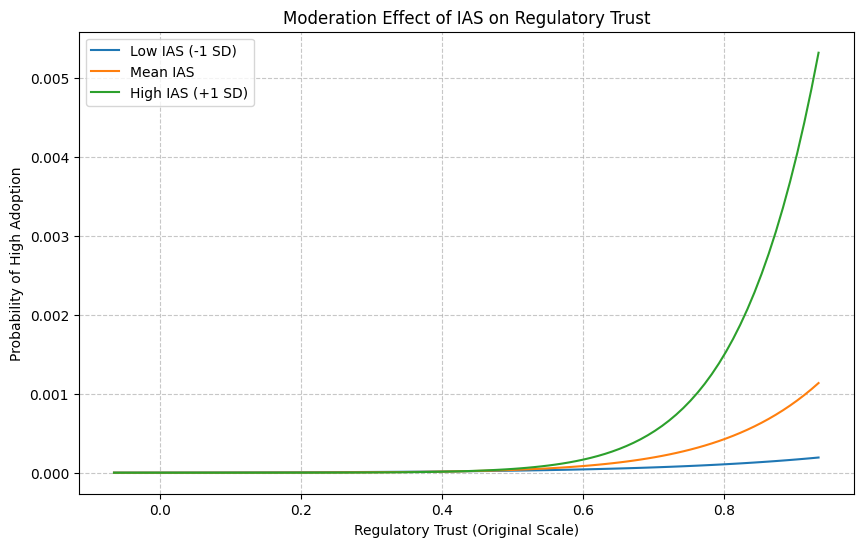

In [67]:
# ============================================================
# APPENDIX H6: MODERATION PLOT (SIMPLE SLOPES)
# ============================================================

# Create a range for the X-axis (Centered Regulatory Trust)
x_range = np.linspace(df_mod2[pred_c].min(), df_mod2[pred_c].max(), 100)

plt.figure(figsize=(10, 6))

# Calculate lines for each level
for label, m_value in moderator_levels.items():
    # Y = intercept + b1*X + b2*M + b3*X*M
    # Note: We use the actual coefficients from moderation_result2
    b0 = moderation_result2.params['const']
    b1 = moderation_result2.params[pred_c]
    b2 = moderation_result2.params[mod_c]
    b3 = moderation_result2.params[interaction_name]

    # Calculate expected Probit value (Linear Predictor)
    # For plotting, we hold other controls at their mean (0 for centered/dummies is a common proxy)
    y_vals = b0 + (b1 * x_range) + (b2 * m_value) + (b3 * x_range * m_value)

    # Convert Probit to Probability
    prob_vals = norm.cdf(y_vals)

    plt.plot(x_range + ias_mean, prob_vals, label=label)

plt.title("Moderation Effect of IAS on Regulatory Trust")
plt.xlabel("Regulatory Trust (Original Scale)")
plt.ylabel("Probability of High Adoption")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

APPENDIX I: XGBoost Model Specification and Performance

STEP 26: Prepare XGBoost Data

In [68]:
# ============================================================
# APPENDIX I1: PREPARE XGBOOST DATA
# ============================================================

xgb_vars = [dependent_var] + main_predictors + control_vars
xgb_vars = [v for v in xgb_vars if v in df.columns]

xgb_df = df[xgb_vars].dropna()

# Encode categorical variables
xgb_df_encoded = pd.get_dummies(xgb_df, drop_first=True, dtype=float)

y_xgb = xgb_df_encoded[dependent_var]
X_xgb = xgb_df_encoded.drop(columns=[dependent_var])

print("XGBoost sample size:", X_xgb.shape[0])
print("Number of predictors after encoding:", X_xgb.shape[1])

X_xgb.head()


XGBoost sample size: 850
Number of predictors after encoding: 10


,REG_TRUST_NORM,IAS_INDEX,DIGLIT,PU,PEOU,owner_age_cat,gender,education_level,staff_size_cat,sector
0,0.833333,0.138889,2.833333,5.00,4.50,2,1,4,3,3
1,0.416667,0.361111,2.333333,3.50,4.00,3,1,7,1,5
2,0.166667,0.833333,2.500000,2.75,3.75,3,1,5,2,1
3,0.666667,0.277778,3.666667,4.50,4.00,3,1,3,2,2
4,0.166667,0.138889,2.333333,4.25,4.00,5,1,7,1,6


STEP 27: Train-Test Split

In [69]:
# ============================================================
# APPENDIX I2: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_xgb,
    y_xgb,
    test_size=0.20,
    random_state=42
)

print("Training sample:", X_train.shape[0])
print("Test sample:", X_test.shape[0])


Training sample: 680
Test sample: 170


###STEP 28: Estimate XGBoost Model

In [70]:
# ============================================================
# APPENDIX I3: XGBOOST MODEL
# ============================================================

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.80,
    colsample_bytree=0.80,
    min_child_weight=1,
    gamma=0,
    reg_alpha=0,
    reg_lambda=1,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost model fitted successfully.")


XGBoost model fitted successfully.


### STEP 29: XGBoost Hyperparameter Table

In [71]:
# ============================================================
# APPENDIX I4: HYPERPARAMETER TABLE
# ============================================================

hyperparameter_table = pd.DataFrame({
    "Hyperparameter": [
        "n_estimators",
        "max_depth",
        "learning_rate",
        "subsample",
        "colsample_bytree",
        "min_child_weight",
        "gamma",
        "reg_alpha",
        "reg_lambda",
        "objective",
        "random_state"
    ],
    "Final Value": [
        300,
        3,
        0.05,
        0.80,
        0.80,
        1,
        0,
        0,
        1,
        "reg:squarederror",
        42
    ]
})

hyperparameter_table


,Hyperparameter,Final Value
0,n_estimators,300
1,max_depth,3
2,learning_rate,0.05
3,subsample,0.8
4,colsample_bytree,0.8
5,min_child_weight,1
6,gamma,0
7,reg_alpha,0
8,reg_lambda,1
9,objective,reg:squarederror


###STEP 30: XGBoost Performance Metrics

In [72]:
# ============================================================
# APPENDIX I5: XGBOOST PERFORMANCE
# ============================================================

y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Cross-validation R-squared
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_scores = cross_val_score(
    xgb_model,
    X_xgb,
    y_xgb,
    cv=kf,
    scoring="r2"
)

performance_table = pd.DataFrame({
    "Metric": [
        "RMSE",
        "MAE",
        "R-squared",
        "CV R-squared Mean",
        "CV R-squared SD"
    ],
    "Training Set": [
        round(train_rmse, 4),
        round(train_mae, 4),
        round(train_r2, 4),
        "",
        ""
    ],
    "Test Set": [
        round(test_rmse, 4),
        round(test_mae, 4),
        round(test_r2, 4),
        "",
        ""
    ],
    "Cross-validation": [
        "",
        "",
        "",
        round(cv_r2_scores.mean(), 4),
        round(cv_r2_scores.std(), 4)
    ]
})

performance_table


,Metric,Training Set,Test Set,Cross-validation
0,RMSE,0.3103,0.4693,
1,MAE,0.2569,0.3977,
2,R-squared,0.6099,0.1066,
3,CV R-squared Mean,,,0.1427
4,CV R-squared SD,,,0.0811


STEP 31: XGBoost Feature Importance

In [73]:
# ============================================================
# APPENDIX I6: XGBOOST FEATURE IMPORTANCE
# ============================================================

xgb_importance_table = pd.DataFrame({
    "Feature": X_xgb.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

xgb_importance_table["Rank"] = range(1, len(xgb_importance_table) + 1)

xgb_importance_table = xgb_importance_table[["Rank", "Feature", "Importance"]].round(4)

xgb_importance_table.head(20)


,Rank,Feature,Importance
2,1,DIGLIT,0.1982
8,2,staff_size_cat,0.1167
0,3,REG_TRUST_NORM,0.1017
4,4,PEOU,0.1007
6,5,gender,0.0909
3,6,PU,0.0872
5,7,owner_age_cat,0.0805
9,8,sector,0.0777
7,9,education_level,0.0754
1,10,IAS_INDEX,0.0712


### APPENDIX J: SHAP Feature Importance

STEP 32: SHAP Values

In [75]:
# ============================================================
# APPENDIX J1: COMPUTE SHAP VALUES (FIXED)
# ============================================================

# Using TreeExplainer specifically for XGBoost to avoid NotImplementedError
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

print("SHAP values computed successfully.")

SHAP values computed successfully.


### STEP 33: SHAP Summary Plot

The summary plot provides an overview of which features are most important for the model and how they influence the predicted probability of high adoption.

STEP 33: Mean Absolute SHAP Table

In [78]:
# ============================================================
# APPENDIX J2: MEAN ABSOLUTE SHAP VALUES
# ============================================================

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

shap_importance_table = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean Absolute SHAP Value": mean_abs_shap
}).sort_values(by="Mean Absolute SHAP Value", ascending=False)

shap_importance_table["Rank"] = range(1, len(shap_importance_table) + 1)

shap_importance_table = shap_importance_table[[
    "Rank", "Feature", "Mean Absolute SHAP Value"
]].round(4)

shap_importance_table.head(15)


,Rank,Feature,Mean Absolute SHAP Value
2,1,DIGLIT,0.1374
0,2,REG_TRUST_NORM,0.1105
8,3,staff_size_cat,0.0633
4,4,PEOU,0.0546
3,5,PU,0.0344
1,6,IAS_INDEX,0.0323
7,7,education_level,0.0278
9,8,sector,0.0255
6,9,gender,0.0209
5,10,owner_age_cat,0.0174


STEP 34: SHAP Summary Plot

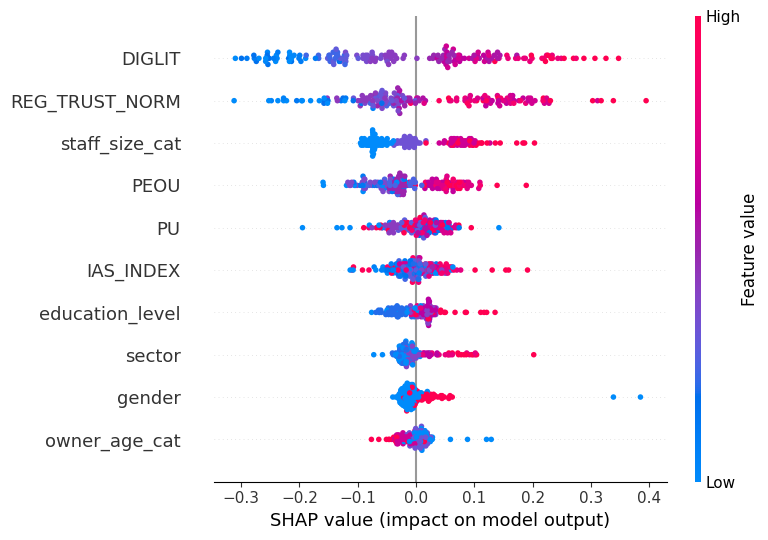

In [84]:
# ============================================================
# APPENDIX J2: SHAP SUMMARY PLOT
# ============================================================

# Generate the SHAP summary plot
shap.summary_plot(shap_values, X_test)

# Note: To show a bar plot of mean absolute SHAP values:
# shap.plots.bar(shap_values)

STEP 35: SHAP Bar Plot


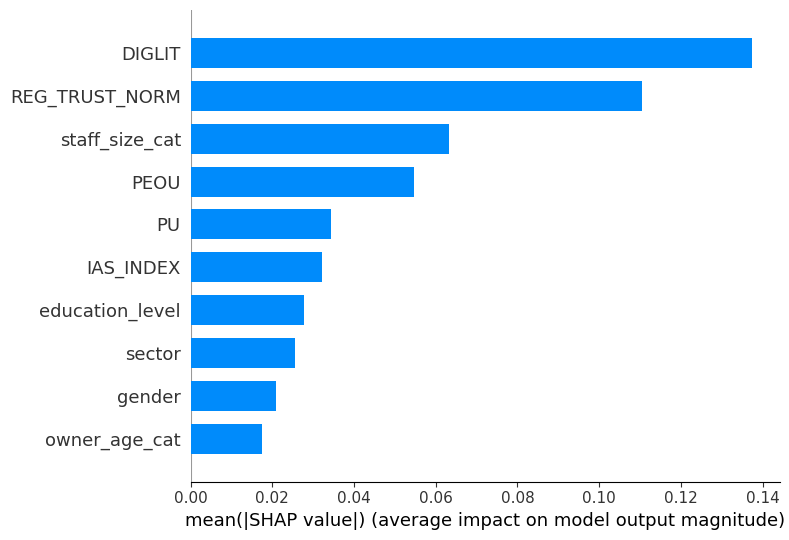

In [80]:
# ============================================================
# APPENDIX J4: SHAP BAR PLOT
# ============================================================

shap.summary_plot(shap_values, X_test, plot_type="bar")



##STEP 36: Export Results

In [86]:
# ============================================================
# EXPORT ALL APPENDIX TABLES TO EXCEL
# ============================================================

output_filename = "Analysis_Appendices_C_to_J_Statistical_Outputs.xlsx"

with pd.ExcelWriter(output_filename, engine="openpyxl") as writer:

    # Appendix C
    alpha_table.to_excel(writer, sheet_name="C_Alpha", index=False)
    kmo_bartlett_table.to_excel(writer, sheet_name="C_KMO_Bartlett", index=False)
    factor_loading_table.to_excel(writer, sheet_name="C_Factor_Loadings")
    eigenvalue_table.to_excel(writer, sheet_name="C_Eigenvalues", index=False)
    variance_table.to_excel(writer, sheet_name="C_Variance_Explained", index=False)
    cr_ave_table.to_excel(writer, sheet_name="C_CR_AVE", index=False)

    # Appendix D
    desc_table.to_excel(writer, sheet_name="D_Descriptive_Stats")
    missing_summary.to_excel(writer, sheet_name="D_Missing_Data", index=False)

    for var, table in frequency_tables.items():
        sheet = f"D_Freq_{var}"[:31]
        table.to_excel(writer, sheet_name=sheet, index=False)

    # Appendix E
    corr_matrix.to_excel(writer, sheet_name="E_Correlation")
    corr_pval_matrix.to_excel(writer, sheet_name="E_Correlation_Pvalues")
    vif_table.to_excel(writer, sheet_name="E_VIF", index=False)

    # Appendix F
    coef_table.to_excel(writer, sheet_name="F_Frac_Probit", index=False)
    model_diagnostics.to_excel(writer, sheet_name="F_Model_Diagnostics", index=False)

    # Appendix G
    ame_table.to_excel(writer, sheet_name="G_AME", index=False)

    # Appendix H
    moderation_table.to_excel(writer, sheet_name="H_Moderation", index=False)
    simple_slopes_table.to_excel(writer, sheet_name="H_Simple_Slopes", index=False)

    # Appendix I
    hyperparameter_table.to_excel(writer, sheet_name="I_XGB_Hyperparameters", index=False)
    performance_table.to_excel(writer, sheet_name="I_XGB_Performance", index=False)
    xgb_importance_table.to_excel(writer, sheet_name="I_XGB_Importance", index=False)

    # Appendix J
    shap_importance_table.to_excel(writer, sheet_name="J_SHAP_Importance", index=False)

print("Export completed:", output_filename)


Export completed: Analysis_Appendices_C_to_J_Statistical_Outputs.xlsx


###STEP 37: Download the Excel Output

In [87]:
# ============================================================
# DOWNLOAD OUTPUT FILE
# ============================================================

# The filename must be a string (in quotes) or a defined variable
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>